In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
import tf_keras
from tf_keras import layers, Model, regularizers, initializers
from tf_keras.callbacks import EarlyStopping

from Functions.distance import euclidean_distance, contrastive_loss

## Seed fissi (per confronti riproducibili tra run)

Senza seed, `data_generator`/`augment_batch` (shuffle e scelta random delle bande da mescolare) e l'inizializzazione dei pesi del modello cambiano ad ogni run, rendendo instabile il confronto fold-per-fold tra versioni diverse del notebook.

In [3]:
import random

GLOBAL_SEED = 42

def set_all_seeds(seed=GLOBAL_SEED):
    seed = int(seed)  # cast esplicito: random.seed() rifiuta np.int64
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_all_seeds()


## Costanti

In [ ]:
N_VAL_SUBJECTS = 10
AUG_FRACTION = 0.2
CONTRASTIVE_MARGIN = 1.0

N_DEBUG_FOLDS = 24     
                       
DEBUG_EPOCHS = 60      
                       
DEBUG_STEPS_PER_EPOCH = 80
DEBUG_PATIENCE = 12

FULL_EPOCHS = 50
FULL_STEPS_PER_EPOCH = 100
FULL_PATIENCE = 8


## Caricamento dati precalcolati

In [5]:
def load_precomputed(power_tensor_path="power_tensor.npy",
                      labels_path="labels.npy",
                      subject_ids_path="subject_ids.npy",
                      brain_maps_path="brain_maps.npy"):
    power_tensor = np.load(power_tensor_path)
    labels = np.load(labels_path)
    subject_ids = np.load(subject_ids_path, allow_pickle=True)
    brain_maps = np.load(brain_maps_path)
    return power_tensor, labels, subject_ids, brain_maps


def split_frequency_bands(brain_maps):
    return {
        "delta": brain_maps[:, :, :, 0:4],
        "theta": brain_maps[:, :, :, 4:8],
        "alpha": brain_maps[:, :, :, 8:12],
        "beta":  brain_maps[:, :, :, 12:35],
        "gamma": brain_maps[:, :, :, 35:40],
    }

## Modello: rete base con attention fra sub-band + rete siamese

`build_siamese` ora include `Dense(1) + Sigmoid` dopo la distanza
euclidea (variante stabile del BatchNorm+Sigmoid di Fig. 5 del paper) —
l'unico cambiamento architetturale rispetto alla versione precedente.

In [6]:
def base_network_att(delta_shape, theta_shape, alpha_shape, beta_shape, gamma_shape,
                      embed_dim=16, num_heads=2, dropout_rate=0.1, l2_reg=1e-5, lc_init_std=1.0):

    input_alpha = layers.Input(shape=alpha_shape, name="alpha_input")
    input_beta  = layers.Input(shape=beta_shape,  name="beta_input")
    input_delta = layers.Input(shape=delta_shape, name="delta_input")
    input_theta = layers.Input(shape=theta_shape, name="theta_input")
    input_gamma = layers.Input(shape=gamma_shape, name="gamma_input")

    lc_alpha = layers.LocallyConnected2D(1, kernel_size=5, activation="hard_sigmoid",
                                          kernel_initializer=initializers.RandomNormal(stddev=lc_init_std, seed=GLOBAL_SEED+0),
                                          kernel_regularizer=regularizers.l2(l2_reg))(input_alpha)
    lc_beta = layers.LocallyConnected2D(1, kernel_size=5, activation="hard_sigmoid",
                                          kernel_initializer=initializers.RandomNormal(stddev=lc_init_std, seed=GLOBAL_SEED+1),
                                          kernel_regularizer=regularizers.l2(l2_reg))(input_beta)
    lc_delta = layers.LocallyConnected2D(1, kernel_size=5, activation="hard_sigmoid",
                                          kernel_initializer=initializers.RandomNormal(stddev=lc_init_std, seed=GLOBAL_SEED+2),
                                          kernel_regularizer=regularizers.l2(l2_reg))(input_delta)
    lc_theta = layers.LocallyConnected2D(1, kernel_size=5, activation="hard_sigmoid",
                                          kernel_initializer=initializers.RandomNormal(stddev=lc_init_std, seed=GLOBAL_SEED+3),
                                          kernel_regularizer=regularizers.l2(l2_reg))(input_theta)
    lc_gamma = layers.LocallyConnected2D(1, kernel_size=5, activation="hard_sigmoid",
                                          kernel_initializer=initializers.RandomNormal(stddev=lc_init_std, seed=GLOBAL_SEED+4),
                                          kernel_regularizer=regularizers.l2(l2_reg))(input_gamma)
    band_maps = [lc_alpha, lc_beta, lc_delta, lc_theta, lc_gamma]

    tokens = []
    for band_map in band_maps:
        pooled = layers.GlobalAveragePooling2D()(band_map)
        token = layers.Dense(embed_dim, activation="tanh",
                              kernel_regularizer=regularizers.l2(l2_reg))(pooled)
        token = layers.Dropout(dropout_rate)(token)
        tokens.append(token)

    token_seq = layers.Lambda(lambda t: tf.stack(t, axis=1))(tokens)

    attn_output, attn_scores = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim, name="band_attention"
    )(token_seq, token_seq, return_attention_scores=True)

    x = layers.Add()([token_seq, attn_output])
    x = layers.LayerNormalization()(x)

    ff = layers.Dense(embed_dim, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
    ff = layers.Dropout(dropout_rate)(ff)
    ff = layers.Dense(embed_dim, kernel_regularizer=regularizers.l2(l2_reg))(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    importance_score = layers.Dense(1, activation="sigmoid")(x)
    importance_score = layers.Reshape((5,), name="importance_score")(importance_score)

    weighted_maps = []
    for i, band_map in enumerate(band_maps):
        weight = layers.Lambda(lambda t, idx=i: t[:, idx:idx+1])(importance_score)
        weight = layers.Reshape((1, 1, 1))(weight)
        weighted_maps.append(layers.Multiply()([band_map, weight]))

    merged = layers.Concatenate(axis=-1)(weighted_maps)

    y = layers.Conv2D(16, kernel_size=5, activation="tanh",
                       kernel_regularizer=regularizers.l2(l2_reg))(merged)
    y = layers.Conv2D(16, kernel_size=5, activation="tanh",
                       kernel_regularizer=regularizers.l2(l2_reg))(y)
    y = layers.Flatten()(y)
    y = layers.Dropout(dropout_rate)(y)
    embedding = layers.Dense(16, activation="tanh", name="embedding",
                              kernel_regularizer=regularizers.l2(l2_reg))(y)

    return Model(
        inputs=[input_alpha, input_beta, input_delta, input_theta, input_gamma],
        outputs=[embedding, importance_score],
        name="base_network_att"
    )


def build_siamese(base_network, alpha_shape, beta_shape, delta_shape, theta_shape, gamma_shape):
    alpha_A = layers.Input(alpha_shape)
    beta_A  = layers.Input(beta_shape)
    delta_A = layers.Input(delta_shape)
    theta_A = layers.Input(theta_shape)
    gamma_A = layers.Input(gamma_shape)

    alpha_B = layers.Input(alpha_shape)
    beta_B  = layers.Input(beta_shape)
    delta_B = layers.Input(delta_shape)
    theta_B = layers.Input(theta_shape)
    gamma_B = layers.Input(gamma_shape)

    embedded_A, _ = base_network([alpha_A, beta_A, delta_A, theta_A, gamma_A])
    embedded_B, _ = base_network([alpha_B, beta_B, delta_B, theta_B, gamma_B])

    distance = layers.Lambda(euclidean_distance, name="distance")([embedded_A, embedded_B])

    model = Model(
        inputs=[[alpha_A, beta_A, delta_A, theta_A, gamma_A],
                [alpha_B, beta_B, delta_B, theta_B, gamma_B]],
        outputs=distance
    )
    return model

## Split LOOCV (train / val / test)

In [7]:
def data_split(n_patients, n_val=N_VAL_SUBJECTS, seed=42):
    rng = np.random.default_rng(seed)
    all_indices = np.arange(n_patients)
    folds = []

    for test_idx in range(n_patients):
        remaining = np.delete(all_indices, test_idx)
        shuffled = rng.permutation(remaining)
        val_idx = shuffled[:n_val]
        train_idx = shuffled[n_val:]

        folds.append({
            "train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": np.array([test_idx]),
        })
    return folds

## Pairing (CORRETTO — niente vincolo one-class)

Le coppie same-class ora includono anche Control-Control (non solo ADHD-ADHD come nella versione paper-aligned): il modello riceve segnale di coesione anche sul gruppo Control, non solo sul contrasto ADHD-vs-Control.

In [8]:
def create_pairs(idx_array, labels):
    positive_indices = []
    negative_indices = []

    for i, j in combinations(range(len(idx_array)), 2):
        li, lj = labels[idx_array[i]], labels[idx_array[j]]
        if li == lj:
            positive_indices.append([i, j])
        else:
            negative_indices.append([i, j])

    positive_indices = np.array(positive_indices, dtype=int).reshape(-1, 2)
    negative_indices = np.array(negative_indices, dtype=int).reshape(-1, 2)
    return positive_indices, negative_indices

## Data augmentation (sub-band shuffling) + generator con wraparound

In [9]:
def augment_batch(alpha, beta, delta, theta, gamma, subj_labels, idx, aug_fraction=AUG_FRACTION):
    bands = {"alpha": alpha, "beta": beta, "delta": delta, "theta": theta, "gamma": gamma}
    n = len(idx)
    out = {name: arr[idx].copy() for name, arr in bands.items()}
    labels_here = subj_labels[idx]

    for band_i, name in enumerate(bands.keys()):
        start = int(band_i * aug_fraction * n)
        end = int((band_i + 1) * aug_fraction * n)
        for pos in range(start, min(end, n)):
            same_class_pool = np.where(subj_labels == labels_here[pos])[0]
            donor = np.random.choice(same_class_pool)
            out[name][pos] = bands[name][donor]

    return out["alpha"], out["beta"], out["delta"], out["theta"], out["gamma"]


def data_generator(epoch_number, positive_indices, negative_indices,
                    train_alpha, train_beta, train_delta, train_theta, train_gamma,
                    train_labels, positive_batch_size, negative_batch_size, steps_per_epoch):

    n_pos, n_neg = len(positive_indices), len(negative_indices)

    for epoch in range(epoch_number):
        np.random.shuffle(positive_indices)
        np.random.shuffle(negative_indices)
        pos_pointer = neg_pointer = 0

        for step in range(steps_per_epoch):
            if pos_pointer + positive_batch_size > n_pos:
                np.random.shuffle(positive_indices)
                pos_pointer = 0
            if neg_pointer + negative_batch_size > n_neg:
                np.random.shuffle(negative_indices)
                neg_pointer = 0

            pos_pairs = positive_indices[pos_pointer:pos_pointer + positive_batch_size]
            neg_pairs = negative_indices[neg_pointer:neg_pointer + negative_batch_size]

            x1_idx = np.concatenate([pos_pairs[:, 0], neg_pairs[:, 0]])
            x2_idx = np.concatenate([pos_pairs[:, 1], neg_pairs[:, 1]])

            x1 = augment_batch(train_alpha, train_beta, train_delta, train_theta, train_gamma,
                                train_labels, x1_idx)
            x2 = augment_batch(train_alpha, train_beta, train_delta, train_theta, train_gamma,
                                train_labels, x2_idx)

            y = np.concatenate([np.ones(len(pos_pairs)), np.zeros(len(neg_pairs))])

            yield [list(x1), list(x2)], y

            pos_pointer += positive_batch_size
            neg_pointer += negative_batch_size

## Training per fold (CORRETTO — normalizzazione senza leakage)

Prima lo z-score veniva calcolato una volta su tutti i 121 soggetti, incluso quello di test — una fuga di informazioni, per quanto piccola. Ora mean/std per banda vengono stimati **solo sui soggetti di training del fold**, e applicati (senza ricalcolo) a validation e test. `train_fold` riceve `bands_raw` (solo ÷10⁻⁵, non normalizzato) e restituisce anche `norm_stats` da riusare in valutazione.

In [10]:
def train_fold(fold, bands_raw, labels, epochs=50, positive_batch_size=16,
               negative_batch_size=16, steps_per_epoch=100, patience=6, verbose=0):

    train_idx, val_idx = fold["train_idx"], fold["val_idx"]

    # Normalizzazione stimata SOLO sul training set del fold (niente leakage)
    norm_stats = {
        name: (arr[train_idx].mean(), arr[train_idx].std() + 1e-8)
        for name, arr in bands_raw.items()
    }
    def normalize(name, idx):
        mean, std = norm_stats[name]
        return (bands_raw[name][idx] - mean) / std

    alpha_maps_shape = bands_raw["alpha"].shape[1:]
    beta_maps_shape = bands_raw["beta"].shape[1:]
    delta_maps_shape = bands_raw["delta"].shape[1:]
    theta_maps_shape = bands_raw["theta"].shape[1:]
    gamma_maps_shape = bands_raw["gamma"].shape[1:]

    shapes = {
        "delta": delta_maps_shape, "theta": theta_maps_shape,
        "alpha": alpha_maps_shape, "beta": beta_maps_shape,
        "gamma": gamma_maps_shape,
    }

    base_network = base_network_att(
        delta_shape=shapes["delta"], theta_shape=shapes["theta"],
        alpha_shape=shapes["alpha"], beta_shape=shapes["beta"], gamma_shape=shapes["gamma"],
    )
    siamese_model = build_siamese(base_network, shapes["alpha"], shapes["beta"],
                                   shapes["delta"], shapes["theta"], shapes["gamma"])
    siamese_model.compile(optimizer="adam", loss=contrastive_loss)

    positive_indices, negative_indices = create_pairs(train_idx, labels)

    train_alpha, train_beta = normalize("alpha", train_idx), normalize("beta", train_idx)
    train_delta = normalize("delta", train_idx)
    train_theta = normalize("theta", train_idx)
    train_gamma = normalize("gamma", train_idx)
    train_labels_rel = labels[train_idx]

    val_pos, val_neg = create_pairs(val_idx, labels)
    val_alpha, val_beta = normalize("alpha", val_idx), normalize("beta", val_idx)
    val_delta = normalize("delta", val_idx)
    val_theta = normalize("theta", val_idx)
    val_gamma = normalize("gamma", val_idx)

    val_x1_idx = np.concatenate([val_pos[:, 0], val_neg[:, 0]])
    val_x2_idx = np.concatenate([val_pos[:, 1], val_neg[:, 1]])

    val_x1 = [val_alpha[val_x1_idx], val_beta[val_x1_idx], val_delta[val_x1_idx],
              val_theta[val_x1_idx], val_gamma[val_x1_idx]]
    val_x2 = [val_alpha[val_x2_idx], val_beta[val_x2_idx], val_delta[val_x2_idx],
              val_theta[val_x2_idx], val_gamma[val_x2_idx]]
    val_y = np.concatenate([np.ones(len(val_pos)), np.zeros(len(val_neg))])

    generator = data_generator(
        epoch_number=epochs,
        positive_indices=positive_indices, negative_indices=negative_indices,
        train_alpha=train_alpha, train_beta=train_beta, train_delta=train_delta,
        train_theta=train_theta, train_gamma=train_gamma, train_labels=train_labels_rel,
        positive_batch_size=positive_batch_size, negative_batch_size=negative_batch_size,
        steps_per_epoch=steps_per_epoch,
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

    history = siamese_model.fit(
        generator, epochs=epochs, steps_per_epoch=steps_per_epoch,
        validation_data=([val_x1, val_x2], val_y),
        callbacks=[early_stop], verbose=verbose,
    )

    return siamese_model, history.history, norm_stats


## Valutazione (CORRETTA — confronto bilanciato con entrambe le classi, stessa normalizzazione del training)

Score continuo e simmetrico: confronta la distanza media verso i riferimenti ADHD **e** Control nel train set. Usa `norm_stats` calcolato in `train_fold` (solo dal training set del fold) per normalizzare test e riferimenti — nessuna statistica calcolata sul soggetto di test.

In [11]:
def evaluate_fold_balanced(fold, bands_raw, labels, subject_ids, siamese_model, norm_stats, eps=1e-8):
    train_idx, test_idx = fold["train_idx"], fold["test_idx"]

    def normalize(name, idx):
        mean, std = norm_stats[name]
        return (bands_raw[name][idx] - mean) / std

    adhd_train_idx = train_idx[labels[train_idx] == 1]
    control_train_idx = train_idx[labels[train_idx] == 0]

    band_names = ["alpha", "beta", "delta", "theta", "gamma"]
    test_inputs = [normalize(name, test_idx) for name in band_names]

    def mean_distance_to(ref_idx):
        n_ref = len(ref_idx)
        ref_inputs = [normalize(name, ref_idx) for name in band_names]
        x1 = [np.repeat(t, n_ref, axis=0) for t in test_inputs]
        x2 = ref_inputs
        distances = siamese_model.predict([x1, x2], verbose=0).ravel()
        return float(distances.mean())

    adhd_distance = mean_distance_to(adhd_train_idx)
    control_distance = mean_distance_to(control_train_idx)

    # score continuo, simmetrico, in [0, 1]: alto -> vicino ad ADHD
    score = control_distance / (adhd_distance + control_distance + eps)
    predicted_label = int(score > 0.5)
    true_label = int(labels[test_idx][0])

    return predicted_label, true_label, score, subject_ids[test_idx][0], adhd_distance, control_distance


## Caricamento dati ed esecuzione split

**Normalizzazione senza leakage**: qui carichiamo solo `bands_raw` (la sola ×10⁻⁵ del paper, senza z-score globale). Lo z-score viene calcolato **dentro ciascun fold**, in `train_fold`, usando solo i soggetti di training — mai il soggetto di test. `evaluate_fold_balanced` riusa quegli stessi `norm_stats` per normalizzare test e riferimenti in modo coerente.

In [12]:
power_tensor, labels, subject_ids, brain_maps = load_precomputed(
    power_tensor_path="power_tensor.npy",
    labels_path="labels.npy",
    subject_ids_path="subject_ids.npy",
    brain_maps_path="brain_maps.npy",
)
bands_raw = split_frequency_bands(brain_maps)

n_patients = len(labels)
folds = data_split(n_patients=n_patients, n_val=N_VAL_SUBJECTS, seed=42)
print("Numero di fold:", len(folds))


Numero di fold: 121


## Esplorazione dati grezzi (EEG raw, elettrodi, brain maps)

Sezione facoltativa, presa da `notebook__2_.ipynb`: richiede il CSV grezzo `adhddata.csv` (non i soli `.npy` precalcolati usati sopra). Serve solo per ispezione visiva, non per il training/valutazione LOOCV.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df_raw = pd.read_csv("adhddata.csv")

channels = ["Fp1","Fp2","F3","F4","C3","C4","P3","P4","O1","O2",
            "F7","F8","T7","T8","P7","P8","Fz","Cz","Pz"]
df_raw.head()


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,...,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,...,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,...,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,...,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,...,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p


### Segnale EEG grezzo (un paziente)

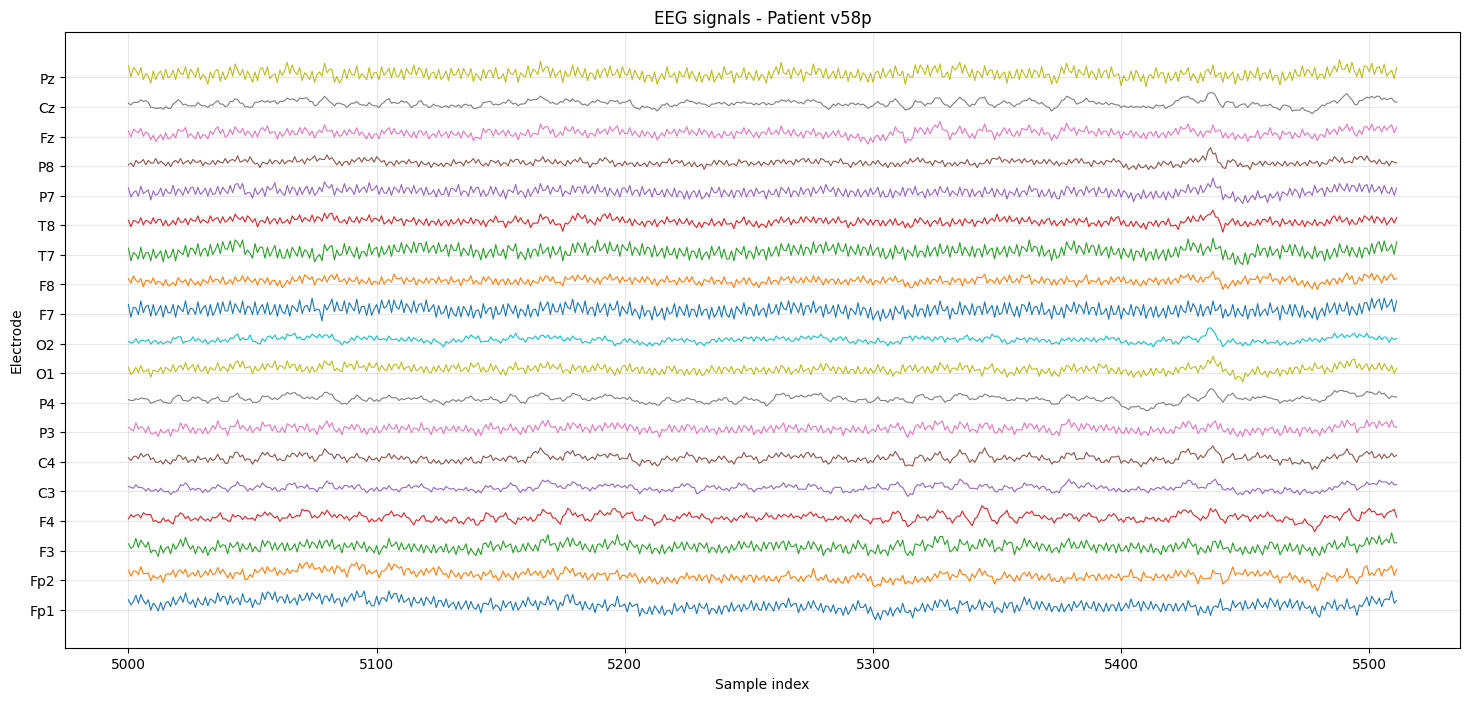

In [14]:
# Cambia patient_id per ispezionare un altro soggetto
patient_id = "v58p"
patient_data = df_raw[df_raw["ID"] == patient_id]
small_part = patient_data[channels].iloc[5000:5512]
x = range(5000, 5512)

plt.figure(figsize=(18, 8))
spacing = small_part.max().max() - small_part.min().min()

for i, ch in enumerate(channels):
    plt.plot(x, small_part[ch] + i * spacing, linewidth=0.8)

plt.yticks([i * spacing for i in range(len(channels))], channels)
plt.xlabel("Sample index")
plt.ylabel("Electrode")
plt.title(f"EEG signals - Patient {patient_id}")
plt.grid(alpha=0.3)
plt.show()


### Posizioni elettrodi (standard 10-20, via MNE)

In [15]:
import mne

montage = mne.channels.make_standard_montage("standard_1020")
coords = montage.get_positions()["ch_pos"]

x_coords, y_coords, z_coords = [], [], []
for ch in channels:
    x_c, y_c, z_c = coords[ch]
    x_coords.append(x_c); y_coords.append(y_c); z_coords.append(z_c)

coords_array = np.array([coords[ch] for ch in channels])
normalized_coords = coords_array / np.linalg.norm(coords_array, axis=1)[:, np.newaxis]

for ch, xyz in zip(channels, normalized_coords):
    print(f"{ch}: ({xyz[0]:.3f}, {xyz[1]:.3f}, {xyz[2]:.3f})")


Fp1: (-0.330, 0.941, -0.078)
Fp2: (0.331, 0.940, -0.078)
F3: (-0.595, 0.629, 0.500)
F4: (0.607, 0.636, 0.478)
C3: (-0.707, -0.126, 0.696)
C4: (0.721, -0.117, 0.683)
P3: (-0.481, -0.715, 0.508)
P4: (0.499, -0.704, 0.507)
O1: (-0.252, -0.965, 0.076)
O2: (0.256, -0.964, 0.076)
F7: (-0.848, 0.512, -0.138)
F8: (0.846, 0.515, -0.139)
T7: (-0.977, -0.186, -0.108)
T8: (0.979, -0.173, -0.109)
P7: (-0.702, -0.712, -0.024)
P8: (0.707, -0.707, -0.025)
Fz: (0.004, 0.661, 0.751)
Cz: (0.004, -0.091, 0.996)
Pz: (0.003, -0.701, 0.714)


In [16]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=x_coords, y=y_coords, z=z_coords,
    mode="markers+text", text=channels, textposition="top center",
    marker=dict(size=6)
))
fig.update_layout(
    title="10-20 EEG Electrode Positions (MNE standard_1020)",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
    width=800, height=800,
)
fig.show()


### Proiezione azimutale equidistante (AEP) degli elettrodi

In [17]:
def aep_projection(xyz):
    x_, y_, z_ = xyz
    phi = np.arcsin(z_)          # latitudine
    lam = np.arctan2(y_, x_)     # longitudine
    c = np.pi / 2 - phi
    X = c * np.sin(lam)
    Y = -c * np.cos(lam)
    return X, Y

aep_coords = {}
for ch in channels:
    xyz = coords[ch] / np.linalg.norm(coords[ch])
    aep_coords[ch] = aep_projection(xyz)
    print(ch, aep_coords[ch])


Fp1 (np.float64(1.5562647435459493), np.float64(0.5459113622412959))
Fp2 (np.float64(1.5557991572459133), np.float64(-0.5474386768383054))
F3 (np.float64(0.7608707409609053), np.float64(0.7197923853102836))
F4 (np.float64(0.7760443105090646), np.float64(-0.740766711016521))
C3 (np.float64(-0.14033037550633923), np.float64(0.7885112851415412))
C4 (np.float64(-0.1312829100262466), np.float64(-0.8083661208270063))
P3 (np.float64(-0.861588965259778), np.float64(0.5796646785189409))
P4 (np.float64(-0.848287504809005), np.float64(-0.6010851047216204))
O1 (np.float64(-1.446239445787657), np.float64(0.3782943317835702))
O2 (np.float64(-1.4448449037430262), np.float64(-0.38444602628875535))
F7 (np.float64(0.8841149299326171), np.float64(1.462542735497995))
F8 (np.float64(0.888666371376423), np.float64(-1.461244090862916))
T7 (np.float64(-0.31402002845558746), np.float64(1.6498386895848953))
T8 (np.float64(-0.29211127515054974), np.float64(-1.6546139610181725))
P7 (np.float64(-1.1356094258564475

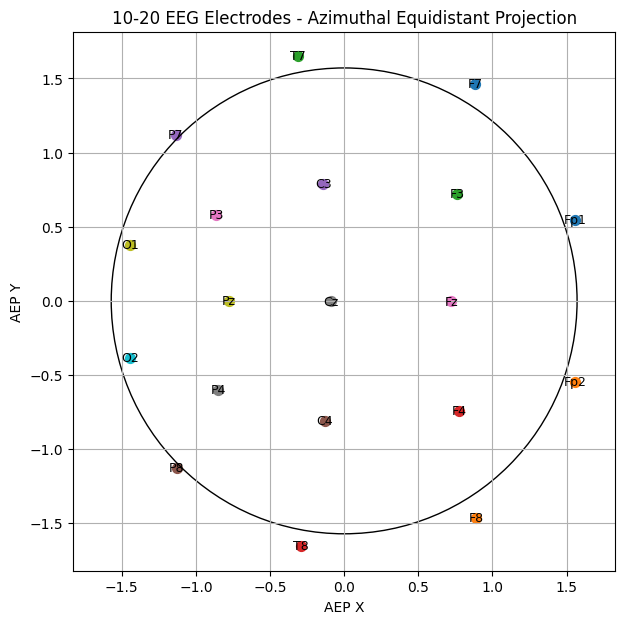

In [18]:
plt.figure(figsize=(7, 7))
for ch, (x_, y_) in aep_coords.items():
    plt.scatter(x_, y_, s=50)
    plt.text(x_, y_, ch, fontsize=9, horizontalalignment="center", verticalalignment="center")

circle = plt.Circle((0, 0), np.pi / 2, fill=False)
plt.gca().add_patch(circle)
plt.axis("equal")
plt.xlabel("AEP X")
plt.ylabel("AEP Y")
plt.title("10-20 EEG Electrodes - Azimuthal Equidistant Projection")
plt.grid(True)
plt.show()


### Confronto brain map ADHD vs Control (6 Hz)

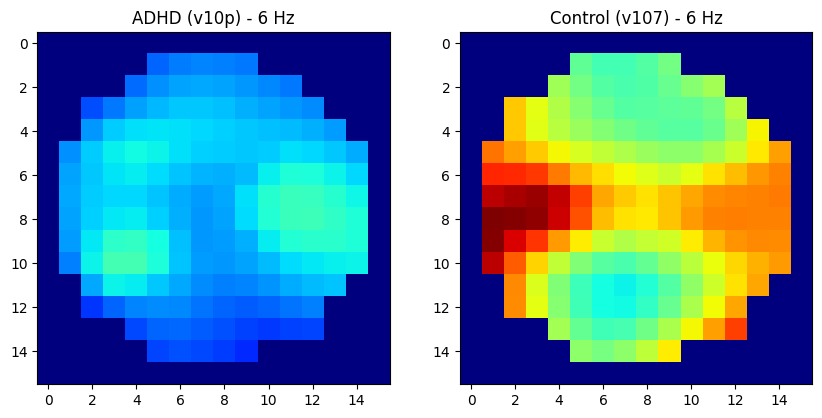

In [19]:
adhd_idx_cmp = np.where(labels == 1)[0][0]
control_idx_cmp = np.where(labels == 0)[0][0]

vmin = min(brain_maps[adhd_idx_cmp, :, :, 6].min(), brain_maps[control_idx_cmp, :, :, 6].min())
vmax = max(brain_maps[adhd_idx_cmp, :, :, 6].max(), brain_maps[control_idx_cmp, :, :, 6].max())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(brain_maps[adhd_idx_cmp, :, :, 6], cmap="jet", vmin=vmin, vmax=vmax)
axes[0].set_title(f"ADHD ({subject_ids[adhd_idx_cmp]}) - 6 Hz")
axes[1].imshow(brain_maps[control_idx_cmp, :, :, 6], cmap="jet", vmin=vmin, vmax=vmax)
axes[1].set_title(f"Control ({subject_ids[control_idx_cmp]}) - 6 Hz")
plt.show()


### Ispezione soggetti sistematicamente sbagliati

`v14p`, `v305`, `v299` sono risultati sbagliati sia con l'architettura con attention sia con quella fedele a Fig. 7 — un indizio che il problema potrebbe essere nei dati di questi soggetti (outlier, rumore, possibile errore di labeling) più che nel modello. Richiede `df_raw` (caricato nella sezione EEG grezzo sopra).

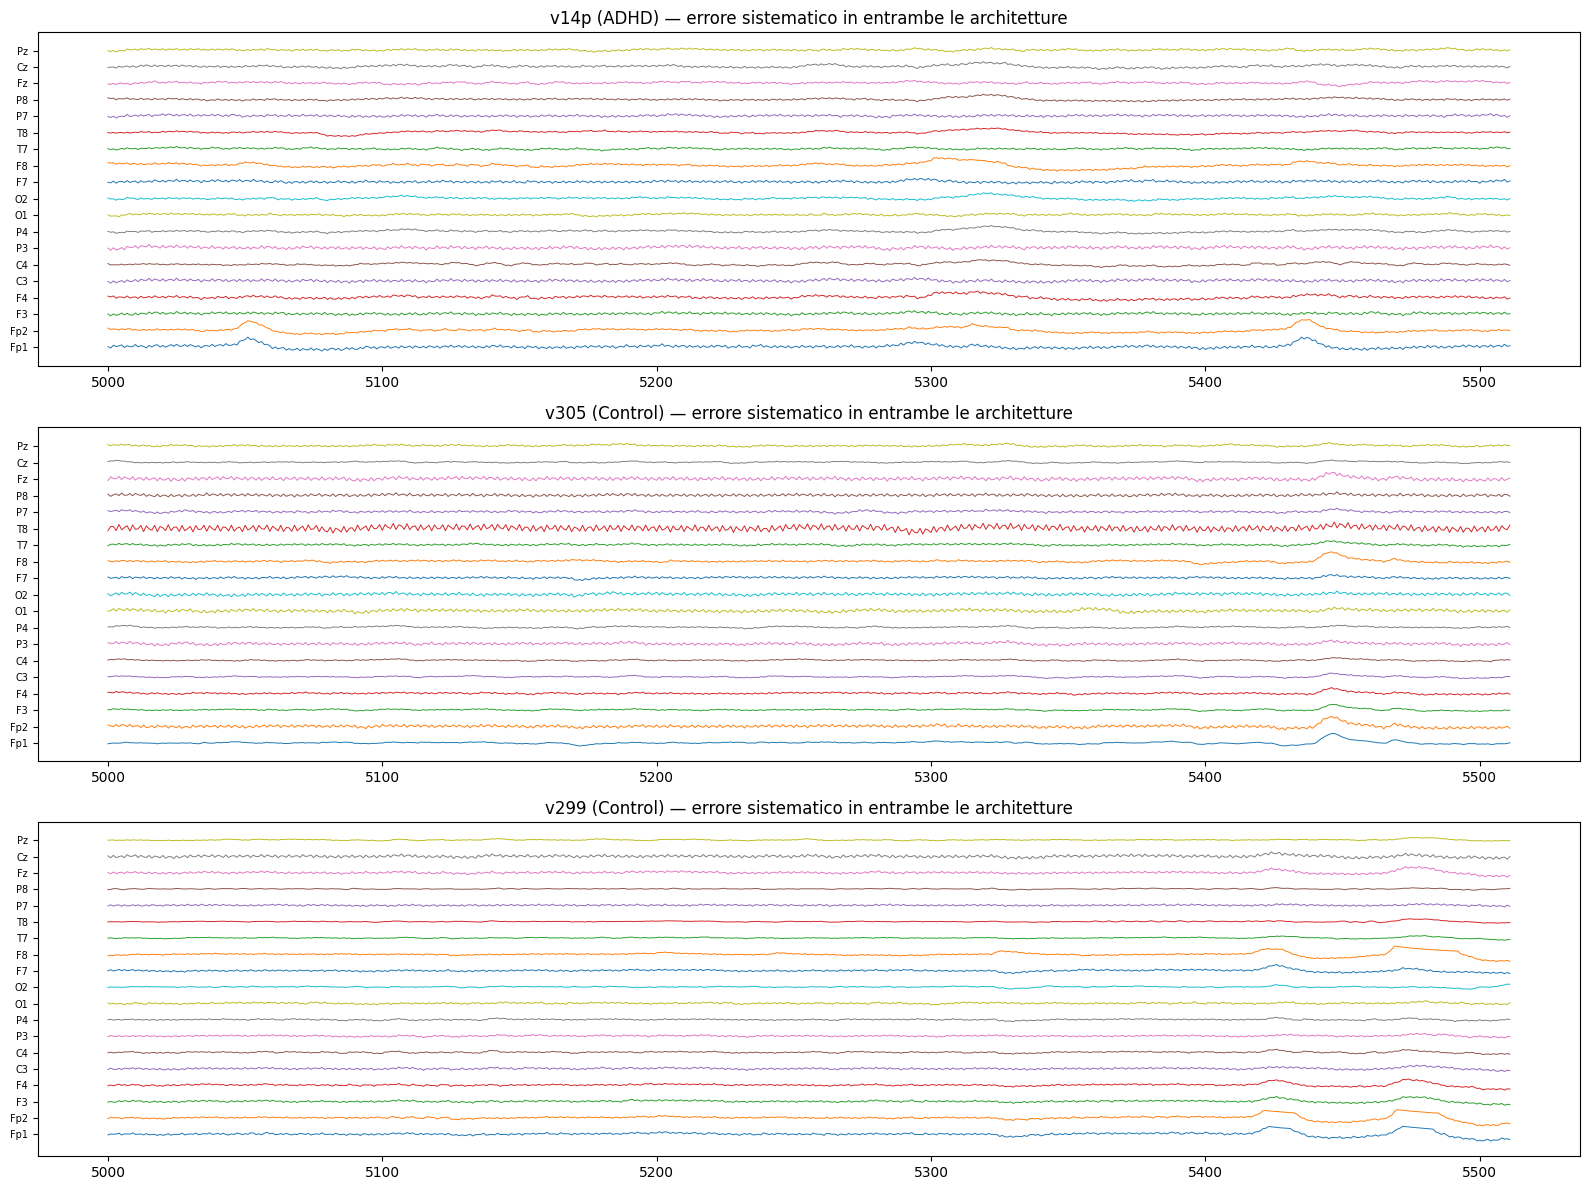

--- v14p ---
           mean         std     min     max
Fp1  146.459059  465.275593 -2061.0  3183.0
Fp2  145.589455  551.301816 -2131.0  3042.0
F3   153.285787  238.955323 -1713.0  3144.0
F4   146.694511  324.102415 -1779.0  2761.0
C3   153.939585  263.923789 -1639.0  3144.0
C4   153.422275  263.958927 -1235.0  2150.0
P3   153.847398  279.406614 -1934.0  3254.0
P4   153.721387  256.822527 -1235.0  2628.0
O1   153.801332  208.020517 -2081.0  2776.0
O2   154.337946  262.098631 -1308.0  2481.0
F7   153.634723  239.099320 -1823.0  2996.0
F8   153.585013  357.603322 -2339.0  2776.0
T7   153.926033  244.926900 -1639.0  2923.0
T8   153.253103  277.012743 -2523.0  2150.0
P7   154.135349  232.042458 -2670.0  3033.0
P8   154.053639  232.572404 -1087.0  2334.0
Fz   148.303098  222.097585 -1850.0  3148.0
Cz   148.696902  278.655853 -1603.0  2233.0
Pz   149.177656  269.242548 -2976.0  3711.0

--- v305 ---
           mean         std     min     max
Fp1  128.249315  290.813840 -1674.0  3077.0
Fp2  

In [20]:
suspect_subjects = ["v14p", "v305", "v299"]

fig, axes = plt.subplots(len(suspect_subjects), 1, figsize=(16, 4 * len(suspect_subjects)))

for ax, sid in zip(axes, suspect_subjects):
    patient_data = df_raw[df_raw["ID"] == sid]
    label = "ADHD" if patient_data["Class"].iloc[0] == "ADHD" else "Control"
    small_part = patient_data[channels].iloc[5000:5512]
    x = range(5000, 5512)
    spacing = small_part.max().max() - small_part.min().min()

    for i, ch in enumerate(channels):
        ax.plot(x, small_part[ch] + i * spacing, linewidth=0.7)

    ax.set_yticks([i * spacing for i in range(len(channels))])
    ax.set_yticklabels(channels, fontsize=7)
    ax.set_title(f"{sid} ({label}) — errore sistematico in entrambe le architetture")

plt.tight_layout()
plt.show()

# Statistiche rapide: valori estremi/piatti possono indicare canali rumorosi o saturati
for sid in suspect_subjects:
    patient_data = df_raw[df_raw["ID"] == sid]
    stats = patient_data[channels].describe().loc[["mean", "std", "min", "max"]]
    print(f"--- {sid} ---")
    print(stats.T[["mean", "std", "min", "max"]])
    print()


### Diagnostica: loss per fold e distribuzione delle distanze

Da `notebook__2_.ipynb`, adattata a `bands`/`folds` già caricati sopra e alla firma attuale di `build_siamese`. Allena solo pochi fold per un controllo rapido (non sostituisce il run LOOCV completo).

In [21]:
def run_fold_diagnostic(fold, bands_raw, labels, subject_ids, patience=10, epochs=50):
    train_idx = fold["train_idx"]
    val_idx   = fold["val_idx"]
    test_idx  = fold["test_idx"]

    # Normalizzazione solo dal training set del fold (niente leakage)
    norm_stats = {
        name: (arr[train_idx].mean(), arr[train_idx].std() + 1e-8)
        for name, arr in bands_raw.items()
    }
    def normalize(name, idx):
        mean, std = norm_stats[name]
        return (bands_raw[name][idx] - mean) / std

    band_names = ["alpha", "beta", "delta", "theta", "gamma"]
    shapes = {name: bands_raw[name].shape[1:] for name in band_names}

    base_network = base_network_att(
        delta_shape=shapes["delta"], theta_shape=shapes["theta"],
        alpha_shape=shapes["alpha"], beta_shape=shapes["beta"], gamma_shape=shapes["gamma"],
    )
    siamese_model = build_siamese(base_network, shapes["alpha"], shapes["beta"],
                                   shapes["delta"], shapes["theta"], shapes["gamma"])
    siamese_model.compile(optimizer="adam", loss=contrastive_loss)

    positive_indices, negative_indices = create_pairs(train_idx, labels)

    val_pos, val_neg = create_pairs(val_idx, labels)
    val_x1_idx = np.concatenate([val_pos[:, 0], val_neg[:, 0]])
    val_x2_idx = np.concatenate([val_pos[:, 1], val_neg[:, 1]])

    val_x1 = [normalize(name, val_idx)[val_x1_idx] for name in band_names]
    val_x2 = [normalize(name, val_idx)[val_x2_idx] for name in band_names]
    val_y = np.concatenate([np.ones(len(val_pos)), np.zeros(len(val_neg))])

    positive_batch_size = 16
    negative_batch_size = 16
    steps_per_epoch = 100

    train_labels_rel = labels[train_idx]
    train_normed = {name: normalize(name, train_idx) for name in band_names}
    generator = data_generator(
        epoch_number=epochs,
        positive_indices=positive_indices, negative_indices=negative_indices,
        train_alpha=train_normed["alpha"], train_beta=train_normed["beta"],
        train_delta=train_normed["delta"], train_theta=train_normed["theta"],
        train_gamma=train_normed["gamma"], train_labels=train_labels_rel,
        positive_batch_size=positive_batch_size, negative_batch_size=negative_batch_size,
        steps_per_epoch=steps_per_epoch,
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

    history = siamese_model.fit(
        generator, epochs=epochs, steps_per_epoch=steps_per_epoch,
        validation_data=([val_x1, val_x2], val_y),
        callbacks=[early_stop], verbose=0,
    )

    test_inputs = [normalize(name, test_idx) for name in band_names]
    n_train = len(train_idx)
    x1 = [np.repeat(t, n_train, axis=0) for t in test_inputs]
    x2 = [train_normed[name] for name in band_names]

    distances = siamese_model.predict([x1, x2], verbose=0)

    train_labels = labels[train_idx]
    adhd_distance = np.mean(distances[train_labels == 1])
    control_distance = np.mean(distances[train_labels == 0])

    predicted_label = 1 if adhd_distance < control_distance else 0
    true_label = labels[test_idx][0]

    return {
        "predicted": predicted_label, "true": true_label,
        "subject_id": subject_ids[test_idx][0],
        "adhd_distance": adhd_distance, "control_distance": control_distance,
        "history": history.history,
    }


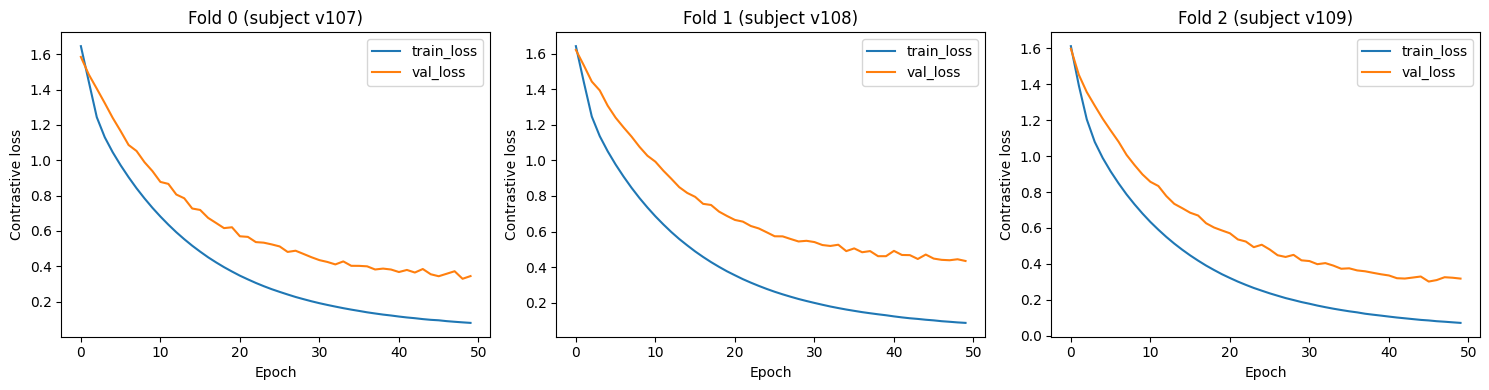

In [22]:
diagnostic_results = []
n_diagnostic_folds = 3 

fig, axes = plt.subplots(1, n_diagnostic_folds, figsize=(5 * n_diagnostic_folds, 4))
if n_diagnostic_folds == 1:
    axes = [axes]

for i in range(n_diagnostic_folds):
    set_all_seeds(seed=GLOBAL_SEED + i)  # stato deterministico per-fold
    result = run_fold_diagnostic(folds[i], bands_raw, labels, subject_ids, patience=6, epochs=50)
    diagnostic_results.append(result)

    axes[i].plot(result["history"]["loss"], label="train_loss")
    axes[i].plot(result["history"]["val_loss"], label="val_loss")
    axes[i].set_title(f"Fold {i} (subject {result['subject_id']})")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Contrastive loss")
    axes[i].legend()

plt.tight_layout()
plt.show()


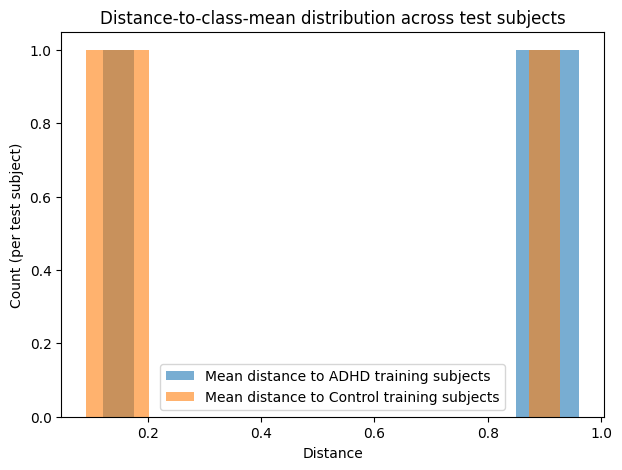

In [23]:
adhd_dists = [r["adhd_distance"] for r in diagnostic_results]
control_dists = [r["control_distance"] for r in diagnostic_results]

plt.figure(figsize=(7, 5))
plt.hist(adhd_dists, bins=15, alpha=0.6, label="Mean distance to ADHD training subjects")
plt.hist(control_dists, bins=15, alpha=0.6, label="Mean distance to Control training subjects")
plt.xlabel("Distance")
plt.ylabel("Count (per test subject)")
plt.title("Distance-to-class-mean distribution across test subjects")
plt.legend()
plt.show()


## Debug rapido (consigliato prima del run completo)

Esegue solo `N_DEBUG_FOLDS` fold, scelti a metà tra soggetti test ADHD e
Control, con training ridotto. Imposta `N_DEBUG_FOLDS = None` sopra per
saltare questa cella.

In [24]:
if N_DEBUG_FOLDS is not None:
    adhd_fold_idx = [i for i, f in enumerate(folds) if labels[f["test_idx"][0]] == 1]
    control_fold_idx = [i for i, f in enumerate(folds) if labels[f["test_idx"][0]] == 0]

    rng = np.random.default_rng(0)
    n_each = N_DEBUG_FOLDS // 2
    debug_fold_idx = list(rng.choice(adhd_fold_idx, size=n_each, replace=False)) + \
                      list(rng.choice(control_fold_idx, size=n_each, replace=False))

    print(f"Fold di debug scelti: {debug_fold_idx}\n")

    dbg_true, dbg_pred, dbg_score = [], [], []

    for i in debug_fold_idx:
        set_all_seeds(seed=GLOBAL_SEED + i)  # stato deterministico per-fold
        fold = folds[i]
        siamese_model, history, norm_stats = train_fold(
            fold, bands_raw, labels,
            epochs=DEBUG_EPOCHS, steps_per_epoch=DEBUG_STEPS_PER_EPOCH,
            patience=DEBUG_PATIENCE, verbose=0,
        )
        pred, true, score, subj, adhd_d, control_d = evaluate_fold_balanced(
            fold, bands_raw, labels, subject_ids, siamese_model, norm_stats
        )
        dbg_true.append(true); dbg_pred.append(pred); dbg_score.append(score)

        correct = "OK" if pred == true else "SBAGLIATO"
        print(f"Fold {i} - soggetto {subj}: vero={true} pred={pred} score={score:.3f} [{correct}]  "
              f"adhd_dist={adhd_d:.4f} control_dist={control_d:.4f}  "
              f"(train_loss={history['loss'][-1]:.4f}, val_loss={history['val_loss'][-1]:.4f}, "
              f"epoche={len(history['loss'])}/{DEBUG_EPOCHS})")

    dbg_true, dbg_pred, dbg_score = np.array(dbg_true), np.array(dbg_pred), np.array(dbg_score)
    print("\n" + "=" * 60)
    print(f"Accuracy debug: {(dbg_true == dbg_pred).mean():.3f}")
    if len(set(dbg_true.tolist())) > 1:
        print(f"AUC debug: {roc_auc_score(dbg_true, dbg_score):.3f}")
    print(f"Frazione predizioni ADHD: {dbg_pred.mean():.3f}  (atteso ~0.5 se bilanciato)")
    print("=" * 60)

Fold di debug scelti: [np.int64(69), np.int64(3), np.int64(53), np.int64(59), np.int64(43), np.int64(37), np.int64(41), np.int64(28), np.int64(65), np.int64(86), np.int64(95), np.int64(31), np.int64(118), np.int64(21), np.int64(106), np.int64(11), np.int64(100), np.int64(109), np.int64(6), np.int64(74), np.int64(1), np.int64(102), np.int64(0), np.int64(99)]

Fold 69 - soggetto v284: vero=1 pred=1 score=0.508 [OK]  adhd_dist=0.5093 control_dist=0.5264  (train_loss=0.1870, val_loss=0.4650, epoche=40/40)
Fold 3 - soggetto v10p: vero=1 pred=1 score=0.708 [OK]  adhd_dist=0.3051 control_dist=0.7397  (train_loss=0.1856, val_loss=0.5043, epoche=40/40)
Fold 53 - soggetto v231: vero=1 pred=0 score=0.083 [SBAGLIATO]  adhd_dist=0.9892 control_dist=0.0896  (train_loss=0.1831, val_loss=0.5535, epoche=40/40)
Fold 59 - soggetto v24p: vero=1 pred=1 score=0.681 [OK]  adhd_dist=0.3588 control_dist=0.7646  (train_loss=0.1893, val_loss=0.5137, epoche=40/40)
Fold 43 - soggetto v204: vero=1 pred=1 score=0.92

## Run completo LOOCV (121 fold — lungo, esegui solo dopo aver validato il debug)

In [25]:
y_true, y_pred, y_score, subj_out = [], [], [], []

for i, fold in enumerate(folds):
    set_all_seeds(seed=GLOBAL_SEED + i)  # stato deterministico per-fold
    siamese_model, history, norm_stats = train_fold(
        fold, bands_raw, labels, epochs=FULL_EPOCHS,
        steps_per_epoch=FULL_STEPS_PER_EPOCH, patience=FULL_PATIENCE, verbose=0
    )
    pred, true, score, subj, adhd_d, control_d = evaluate_fold_balanced(
        fold, bands_raw, labels, subject_ids, siamese_model, norm_stats
    )

    y_true.append(true)
    y_pred.append(pred)
    y_score.append(score)
    subj_out.append(subj)

    print(f"Fold {i + 1}/{len(folds)} - subject {subj}: pred={pred} true={true} score={score:.3f}")

Fold 1/121 - subject v107: pred=0 true=0 score=0.181
Fold 2/121 - subject v108: pred=0 true=0 score=0.087
Fold 3/121 - subject v109: pred=1 true=0 score=0.885
Fold 4/121 - subject v10p: pred=1 true=1 score=0.846


KeyboardInterrupt: 

## Metriche finali

In [ ]:
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)

print(f"\nLOOCV Accuracy: {acc:.3f}")
print(f"LOOCV AUC: {auc:.3f}")
print("Confusion matrix:\n", cm)
print(f"Frazione predizioni ADHD: {np.mean(y_pred):.3f}  (atteso ~0.5 se bilanciato)")

## Curva ROC

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_score)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LOOCV (majority vote, come nel paper)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Importanza delle bande (attention) — ADHD vs Control

Il blocco attention dentro `base_network_att` calcola già `importance_score`
per ciascuna delle 5 sub-band ad ogni forward pass — è la vostra estensione
rispetto al paper, che invece doveva ricorrere a Grad-CAM a posteriori per
capire quali regioni/bande contassero di più.

Qui alleniamo un fold, estraiamo `base_network` dal `siamese_model` allenato
(è condiviso tra i due rami — lo recuperiamo per nome), e lo usiamo
direttamente su un soggetto ADHD e uno Control per confrontare visivamente
i pesi di importanza per banda. Nessun Grad-CAM necessario.

In [ ]:

# Alleniamo un fold di esempio (puoi cambiare quale)
example_fold = folds[0]
siamese_model_ex, history_ex, norm_stats_ex = train_fold(
    example_fold, bands_raw, labels,
    epochs=DEBUG_EPOCHS, steps_per_epoch=DEBUG_STEPS_PER_EPOCH,
    patience=DEBUG_PATIENCE, verbose=0,
)

# base_network e' condivisa tra i due rami del siamese: la recuperiamo per nome
base_network_ex = siamese_model_ex.get_layer("base_network_att")

# Un soggetto ADHD e uno Control presi dal train set del fold (qualsiasi soggetto va bene)
train_idx = example_fold["train_idx"]
adhd_idx_ex = train_idx[labels[train_idx] == 1][0]
control_idx_ex = train_idx[labels[train_idx] == 0][0]

def get_importance(subj_idx):
    def normalize(name):
        mean, std = norm_stats_ex[name]
        return (bands_raw[name][subj_idx:subj_idx+1] - mean) / std
    inputs = [normalize("alpha"), normalize("beta"), normalize("delta"),
              normalize("theta"), normalize("gamma")]
    _, importance = base_network_ex.predict(inputs, verbose=0)
    return importance[0]  # shape (5,): alpha, beta, delta, theta, gamma

importance_adhd = get_importance(adhd_idx_ex)
importance_control = get_importance(control_idx_ex)

band_names = ["Alpha", "Beta", "Delta", "Theta", "Gamma"]
x = np.arange(len(band_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, importance_adhd, width, label=f"ADHD ({subject_ids[adhd_idx_ex]})", color="tab:red")
ax.bar(x + width/2, importance_control, width, label=f"Control ({subject_ids[control_idx_ex]})", color="tab:blue")
ax.set_xticks(x)
ax.set_xticklabels(band_names)
ax.set_ylabel("Importance score (0-1)")
ax.set_title("Importanza delle sub-band per soggetto (dal blocco attention)")
ax.legend()
plt.tight_layout()
plt.show()

print("Importance ADHD:  ", dict(zip(band_names, importance_adhd.round(3))))
print("Importance Control:", dict(zip(band_names, importance_control.round(3))))
